In [31]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

# import missingno as msno

from sklearn.model_selection import GridSearchCV

# from sklearn.model_selection import KFold, cross_val_scor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



# 데이터 불러오기

In [35]:
# train_data_path = join('../input', 'train.csv')
# sub_data_path = join('../input', 'test.csv')

# data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/data')
data_dir = './data'

# hint : os.getenv를 사용하거나 직접 경로를 작성

train_data_path = os.path.join(data_dir, 'train.csv')
sub_data_path = os.path.join(data_dir, 'test.csv')      # 테스트, 즉 submission 시 사용할 데이터 경로

print(train_data_path)
print(sub_data_path)

./data/train.csv
./data/test.csv


In [38]:
data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (8693, 14)
sub data dim : (4277, 13)


# 데이터 준비

In [40]:
y = data['Transported']
del data['Transported']

# 데이터 탐색 및 전처리
- 범주형은 원핫 인코딩으로 변환 후 불필요한 열 삭제


In [ ]:
train_len = len(data)
data = pd.concat((data, sub), axis=0)

In [ ]:
data.info()

In [ ]:
data.head()

In [ ]:
data['group'] = data['PassengerId'].apply(lambda x: x.split('_')[0])
data['gnum'] = data['PassengerId'].apply(lambda x: x.split('_')[1])

In [ ]:
data.head()

In [ ]:
planet = pd.get_dummies(data['HomePlanet'])
planet.head()

In [12]:
data = pd.concat([data, planet], axis=1)
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,group,gnum,Earth,Europa,Mars
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0001,01,False,True,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,0002,01,True,False,False
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0003,01,False,True,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0003,02,False,True,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,0004,01,True,False,False


In [13]:
# data[data.isnull().any(axis=1)].sum()
data.isnull().sum()

PassengerId       0
HomePlanet      288
CryoSleep       310
Cabin           299
Destination     274
Age             270
VIP             296
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Name            294
group             0
gnum              0
Earth             0
Europa            0
Mars              0
dtype: int64

In [14]:
data['cdeck'] = data['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else x)
data['cnum'] = data['Cabin'].apply(lambda x: x.split('/')[1] if pd.notna(x) else x)
data['cside'] = data['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else x)

In [15]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,group,gnum,Earth,Europa,Mars,cdeck,cnum,cside
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,0001,01,False,True,False,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,44.0,Juanna Vines,0002,01,True,False,False,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,49.0,Altark Susent,0003,01,False,True,False,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,193.0,Solam Susent,0003,02,False,True,False,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,2.0,Willy Santantines,0004,01,True,False,False,F,1,S


In [16]:
cdeck = pd.get_dummies(data['cdeck'])
cdeck.head()

,A,B,C,D,E,F,G,T
0,False,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False


In [17]:
cside = pd.get_dummies(data['cside'])
cside.head()

,P,S
0,True,False
1,False,True
2,False,True
3,False,True
4,False,True


In [18]:
destination = pd.get_dummies(data['Destination'])
destination.head()

,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True


In [19]:
data = pd.concat([data, cdeck, cside, destination], axis=1)
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,D,E,F,G,T,P,S,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,False,False,False,False,False,True,False,False,False,True
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,False,False,True,False,False,False,True,False,False,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,False,False,False,False,False,False,True,False,False,True
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,False,False,False,False,False,False,True,False,False,True
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,False,False,True,False,False,False,True,False,False,True


In [20]:
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (12970, 34)
sub data dim : (4277, 13)


In [21]:
data.drop(['PassengerId', 'HomePlanet', 'Cabin', 'cdeck', 'cside',  'Destination', 'Name'], axis=1, inplace=True)

In [22]:
data.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group,gnum,...,D,E,F,G,T,P,S,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,01,...,False,False,False,False,False,True,False,False,False,True
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,01,...,False,False,True,False,False,False,True,False,False,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,01,...,False,False,False,False,False,False,True,False,False,True
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,02,...,False,False,False,False,False,False,True,False,False,True
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,01,...,False,False,True,False,False,False,True,False,False,True


# 시각화

In [23]:
sub = data.iloc[train_len:, :]
data = data.iloc[:train_len, :]
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (8693, 27)
sub data dim : (4277, 27)


In [25]:
data = pd.concat([data, y], axis=1)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (8693, 28)
sub data dim : (4277, 27)


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0 to 8692
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CryoSleep      8476 non-null   object 
 1   Age            8514 non-null   float64
 2   VIP            8490 non-null   object 
 3   RoomService    8512 non-null   float64
 4   FoodCourt      8510 non-null   float64
 5   ShoppingMall   8485 non-null   float64
 6   Spa            8510 non-null   float64
 7   VRDeck         8505 non-null   float64
 8   group          8693 non-null   object 
 9   gnum           8693 non-null   object 
 10  Earth          8693 non-null   bool   
 11  Europa         8693 non-null   bool   
 12  Mars           8693 non-null   bool   
 13  cnum           8494 non-null   object 
 14  A              8693 non-null   bool   
 15  B              8693 non-null   bool   
 16  C              8693 non-null   bool   
 17  D              8693 non-null   bool   
 18  E            

- 조건별 그래프 출력

In [ ]:
# print(data.columns)
fig = plt.figure(figsize=(20,7))
#  14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
cols = [0, 2, 8, 9, 10, 11, 12, 13, 24, 25, 26]
for i in range(1, 30):
    ax1 = fig.add_subplot(10,3,i)
    sns.barplot(data=data, x=data.columns[cols[i-1]], y='Transported')
    i += 1
    if i == (len(cols)+1):
        break

# 전처리 2

In [351]:
# sub = data.iloc[train_len:, :]
# x = data.iloc[:train_len, :]
# print('train data dim : {}'.format(data.shape))
# print('sub data dim : {}'.format(sub.shape))

In [401]:
# trade.dropna(how='all', subset=['수출건수', '수출금액', '수입건수', '수입금액', '무역수지'], inplace=True)
data = pd.concat([x, y], axis=1)
data.dropna(how='any', inplace=True)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (7084, 28)
sub data dim : (4277, 27)


In [353]:
data.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group,gnum,...,E,F,G,T,P,S,55 Cancri e,PSO J318.5-22,TRAPPIST-1e,Transported
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,01,...,False,False,False,False,True,False,False,False,True,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,01,...,False,True,False,False,False,True,False,False,True,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,01,...,False,False,False,False,False,True,False,False,True,False
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,02,...,False,False,False,False,False,True,False,False,True,False
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,01,...,False,True,False,False,False,True,False,False,True,True


In [354]:
y = data['Transported']
del data['Transported']
# passengerId = data['PassengerId']
# del data['PassengerId']
# x = data
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (7084, 27)
sub data dim : (4277, 27)


In [355]:
x.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group,gnum,...,D,E,F,G,T,P,S,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,01,...,False,False,False,False,False,True,False,False,False,True
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,01,...,False,False,True,False,False,False,True,False,False,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,01,...,False,False,False,False,False,False,True,False,False,True
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,02,...,False,False,False,False,False,False,True,False,False,True
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,01,...,False,False,True,False,False,False,True,False,False,True


In [356]:
sub.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group,gnum,...,D,E,F,G,T,P,S,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,True,27.0,False,0.0,0.0,0.0,0.0,0.0,0013,01,...,False,False,False,True,False,False,True,False,False,True
1,False,19.0,False,0.0,9.0,0.0,2823.0,0.0,0018,01,...,False,False,True,False,False,False,True,False,False,True
2,True,31.0,False,0.0,0.0,0.0,0.0,0.0,0019,01,...,False,False,False,False,False,False,True,True,False,False
3,False,38.0,False,0.0,6652.0,0.0,181.0,585.0,0021,01,...,False,False,False,False,False,False,True,False,False,True
4,False,20.0,False,10.0,0.0,635.0,0.0,0.0,0023,01,...,False,False,True,False,False,False,True,False,False,True


- 정규화 시도. 효과는 없는 듯함

In [358]:
%%time
scaler = MinMaxScaler()
scaler.fit_transform(x)

CPU times: user 25.1 ms, sys: 3.85 ms, total: 28.9 ms
Wall time: 27.5 ms


array([[0.        , 0.49367089, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.30379747, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.73417722, 1.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.        , 0.32911392, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.40506329, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.55696203, 0.        , ..., 0.        , 0.        ,
        1.        ]], shape=(7084, 27))

In [359]:
scaler.transform(sub)

array([[1.        , 0.34177215, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.24050633, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.39240506, 0.        , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [1.        ,        nan, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        ,        nan, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.5443038 , 0.        , ..., 0.        , 1.        ,
        0.        ]], shape=(4277, 27))

In [366]:
sub.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group,gnum,...,D,E,F,G,T,P,S,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,True,27.0,False,0.0,0.0,0.0,0.0,0.0,0013,01,...,False,False,False,True,False,False,True,False,False,True
1,False,19.0,False,0.0,9.0,0.0,2823.0,0.0,0018,01,...,False,False,True,False,False,False,True,False,False,True
2,True,31.0,False,0.0,0.0,0.0,0.0,0.0,0019,01,...,False,False,False,False,False,False,True,True,False,False
3,False,38.0,False,0.0,6652.0,0.0,181.0,585.0,0021,01,...,False,False,False,False,False,False,True,False,False,True
4,False,20.0,False,10.0,0.0,635.0,0.0,0.0,0023,01,...,False,False,True,False,False,False,True,False,False,True


# 모델링

- 의사결정 트리로 학습 및 Accuracy 측정


In [367]:
random_state=25

In [368]:
def get_scores(models, train, y):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # df[model_name] = rmse(y_test, y_pred)
        # score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)
        # print(model_name, score_df)

    return y_test, y_pred

In [369]:
model = DecisionTreeClassifier(random_state=random_state)
model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [370]:
cols  = ['RoomService', 'FoodCourt',  'ShoppingMall',  'Spa', 'VRDeck']  

In [371]:
y_test, y_pred = get_scores([model], x, y)

# Accuracy

In [372]:
confusion_matrix(y_test, y_pred)

array([[514, 173],
       [164, 566]])

In [373]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.76      0.75      0.75       687
        True       0.77      0.78      0.77       730

    accuracy                           0.76      1417
   macro avg       0.76      0.76      0.76      1417
weighted avg       0.76      0.76      0.76      1417



In [374]:


# 코드 작성
def save_submission(model, train, y, test, model_name, rmsle=None):
    # model.fit(train, y)
    prediction = model.predict(test)
    # prediction = np.expm1(prediction)
    data_dir = './data'
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['Transported'] = prediction
    # submission['Transported'] = transported
    submission_csv_path = '{}/submission_{}.csv'.format(data_dir, model_name)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

In [375]:
save_submission(model, x, y, sub, 'tree')

./data/submission_tree.csv saved!


# 회고
- 70%대의 성눙우로 향상을 위한 시각화, 구간화, 알고리즘 변경 및 파라미터 조정 등 다른 시도 필요 

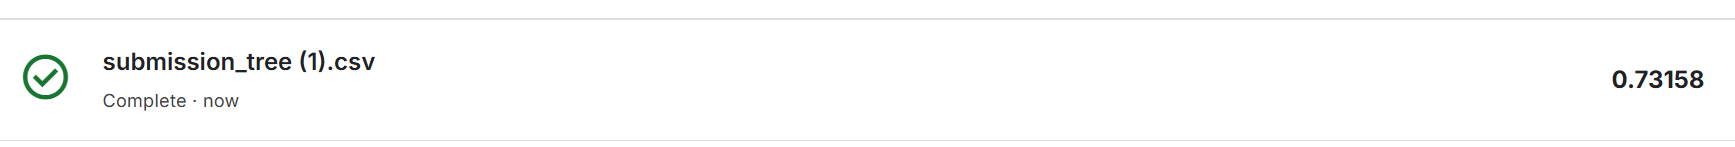